In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("data/dataset_financier_clean.csv")
df.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence_freq,banque_freq,lieu_freq
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,0.323,0.238,0.266
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,0.323,0.260,0.251
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,0.342,0.260,0.266
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,0.323,0.260,0.251
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,0.323,0.251,0.266


<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">I. ANN Building</p>

<a class="btn" href="#home">📅 ANN Constructing</a>

In [41]:
# importation des librairies
import tensorflow as tf
print(tf.__version__)

2.20.0


In [42]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [43]:
# séparer X et Y
X = df.drop('depenses', axis=1)
y = df['depenses']

In [44]:
# spliter X_train et x-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [45]:
# standardisation de X_train X_test, Y-train et Y-test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
# je veux voir la taille de mon dataset
df.shape

(1000, 10)

In [47]:
# Build model
"""nous allons rajouter Dropout pour éviter le overfit en éteignant aléatoirement des neurones pendant l’entraînement
"""
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))

e:\M2_s1\all_environements\ml_env1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
# resumé du model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Compilation
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)


In [50]:
"""restore_best_weights restaure automatiquement,
    les poids du modèle correspondant à l'epoch qui avait la meilleure performance sur val_loss"""
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=10,
    min_lr=0.001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min', # Sauvegarde quand val_loss DIMINUE
    verbose=1
)

In [51]:
# Entraînement avec tous les callbacks
history = model.fit(
    X_train, y_train,
    epochs=10000,
    batch_size=32,
    validation_split=0.2, #pour la validation pendant le training
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/10000


 1/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 2023193.7500 - mean_squared_error: 2023193.7500
Epoch 1: val_loss improved from None to 2599530.00000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2443522.0000 - mean_squared_error: 2443522.0000 - val_loss: 2599530.0000 - val_mean_squared_error: 2599530.0000 - learning_rate: 0.0010
Epoch 2/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2567284.0000 - mean_squared_error: 2567284.0000
Epoch 2: val_loss improved from 2599530.00000 to 2597839.25000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2441995.0000 - mean_squared_error: 2441995.0000 - val_loss: 2597839.2500 - val_mean_squared_error: 2597839.2500 - learning_rate: 0.0010
Epoch 3/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2319842.5000 - mean_squared_error: 2319842.5000
Epoch 3: val_loss improved from 2597839.25000 to 2595114.75000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2440000.7500 - mean_squared_error: 2440000.7500 - val_loss: 2595114.7500 - val_mean_squared_error: 2595114.7500 - learning_rate: 0.0010
Epoch 4/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2832229.7500 - mean_squared_error: 2832229.7500
Epoch 4: val_loss improved from 2595114.75000 to 2590339.75000, saving model to best_model.h5


...

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 303499.8125 - mean_squared_error: 303499.8125 - val_loss: 288555.4062 - val_mean_squared_error: 288555.4062 - learning_rate: 0.0010
Epoch 166/10000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 253635.1258 - mean_squared_error: 253635.1258 
Epoch 166: val_loss improved from 288555.40625 to 287793.84375, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 300327.9062 - mean_squared_error: 300327.9062 - val_loss: 287793.8438 - val_mean_squared_error: 287793.8438 - learning_rate: 0.0010
Epoch 167/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 210804.5312 - mean_squared_error: 210804.5312
Epoch 167: val_loss did not improve from 287793.84375
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 325969.5625 - mean_squared_error: 325969.5625 - val_loss: 288759.3125 - val_mean_squared_error: 288759.3125 - learning_rate: 0.0010
Epoch 168/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 255691.7500 - mean_squared_error: 255691.7500
Epoch 168: val_loss improved from 287793.84375 to 287639.18750, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 319517.4062 - mean_squared_error: 319517.4062 - val_loss: 287639.1875 - val_mean_squared_error: 287639.1875 - learning_rate: 0.0010
Epoch 169/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 295029.0938 - mean_squared_error: 295029.0938
Epoch 169: val_loss improved from 287639.18750 to 287417.43750, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 320188.1562 - mean_squared_error: 320188.1562 - val_loss: 287417.4375 - val_mean_squared_error: 287417.4375 - learning_rate: 0.0010
Epoch 170/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 327745.2500 - mean_squared_error: 327745.2500
Epoch 170: val_loss improved from 287417.43750 to 284921.75000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 318560.4375 - mean_squared_error: 318560.4375 - val_loss: 284921.7500 - val_mean_squared_error: 284921.7500 - learning_rate: 0.0010
Epoch 171/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 332070.8750 - mean_squared_error: 332070.8750
Epoch 171: val_loss did not improve from 284921.75000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 314777.0938 - mean_squared_error: 314777.0938 - val_loss: 284972.7500 - val_mean_squared_error: 284972.7500 - learning_rate: 0.0010
Epoch 172/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 264553.4688 - mean_squared_error: 264553.4688
Epoch 172: val_loss did not improve from 284921.75000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 308634.9375 - mean_squared_error: 308634.9375 - val_loss: 285016.1562 - val_mean_squared_error: 285016.1562 - learning_rate: 0.0010
Epoch 173/10000
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 381002.7500 - mean_squared_error: 381002.7500
Epoch 173: val_loss did 

In [52]:
# quelles sont les critères d'évaluation de mon training
print(history.history.keys())

dict_keys(['loss', 'mean_squared_error', 'val_loss', 'val_mean_squared_error', 'learning_rate'])


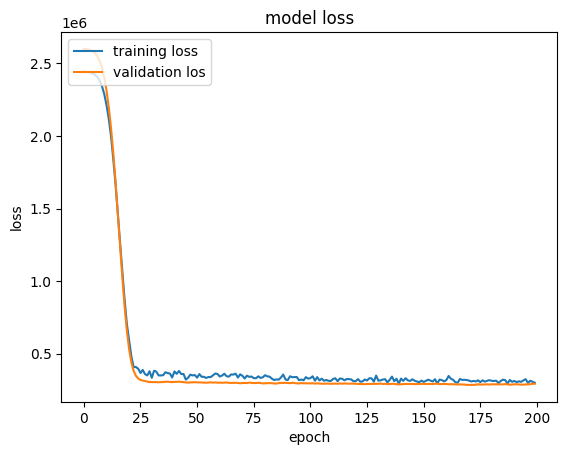

<module 'matplotlib.pyplot' from 'e:\\M2_s1\\all_environements\\ml_env1\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [53]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training loss', 'validation los'], loc='upper left')
plt.show()
plt

<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">III. ANN Evaluating</p>

<a class="btn" href="#home">📅 ANN Evaluating</a>

In [54]:
#Prediction
y_pred_train = model.predict(X_train)
y_pred_train

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[1572.7605],
       [1717.8165],
       [1557.2437],
       [1548.5419],
       [1884.3246],
       [1296.9294],
       [1342.3826],
       [1396.895 ],
       [1413.6201],
       [1517.713 ],
       [1384.4143],
       [1370.1863],
       [1681.4187],
       [1586.1241],
       [1477.0026],
       [1441.8328],
       [1479.0803],
       [1568.9153],
       [1381.9116],
       [1406.2296],
       [1854.7664],
       [1406.4452],
       [1421.9214],
       [1622.9148],
       [1606.8922],
       [1454.1375],
       [1626.0532],
       [1404.2229],
       [1409.0186],
       [1507.5249],
       [1298.7178],
       [1379.6628],
       [1353.4229],
       [1542.4995],
       [1374.177 ],
       [1463.3612],
       [1482.8191],
       [1417.4622],
       [1546.6111],
       [1358.2311],
       [1676.3689],
       [1666.1045],
       [1460.4539],
       [1182.7095],
       [1353.1603],
       [1289.3765],
       [1608.4103],
       [1440.6492],
       [1335.6118],
       [1653.4495],


In [55]:
y_pred_test = model.predict(X_test)
y_pred_test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


array([[1503.1798],
       [1378.8718],
       [1419.5356],
       [1264.449 ],
       [1311.2869],
       [1305.0835],
       [1640.3779],
       [1629.1274],
       [1451.105 ],
       [1244.1221],
       [1521.7739],
       [1643.0205],
       [1427.2156],
       [1418.4492],
       [1091.8561],
       [1533.9021],
       [1380.2161],
       [1327.0442],
       [1577.3414],
       [1570.2161],
       [1462.7042],
       [1388.2617],
       [1444.6858],
       [1603.0009],
       [1202.8911],
       [1313.0503],
       [1834.4651],
       [1453.9498],
       [1174.5933],
       [1553.0776],
       [1706.0736],
       [1628.3446],
       [1531.5967],
       [1345.1279],
       [1368.0828],
       [1368.6606],
       [1350.0786],
       [1222.1726],
       [1326.7502],
       [1543.839 ],
       [1539.0133],
       [1425.2598],
       [1572.4556],
       [1569.9971],
       [1365.666 ],
       [1312.0757],
       [1276.9541],
       [1400.8303],
       [1433.5818],
       [1413.122 ],


In [56]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
MSE = mean_squared_error(y_test, y_pred_test)
r2_score(y_train, y_pred_train)
RMSE = root_mean_squared_error(y_test, y_pred_test)

print(f"MSE: {MSE}")
print(f"R2 score: {r2_score(y_train, y_pred_train)}")
print(f"RMSE", RMSE)

MSE: 271075.3965751486
R2 score: 0.0371997683505636
RMSE 520.6490147644079


In [57]:
df.columns

Index(['bilan_financier', 'actifs', 'revenu', 'depenses', 'taux_interet',
       'flux_tresorerie', 'capital', 'agence_freq', 'banque_freq',
       'lieu_freq'],
      dtype='object')

In [58]:
# load model et prédiction
# Charger le modèle
model = tf.keras.models.load_model("best_model.h5")
X_test = np.array([[50000, 20000, 2500, 5, 8000, 40000, 0.342, 0.260, 0.266]])


In [59]:
# Prédiction
y_pred = model.predict(X_test, verbose=0)

print("Prédiction :", y_pred)

Prédiction : [[12740412.]]
